<a href="https://colab.research.google.com/github/rifkiabdulaziz-lab/uts_basis-data_6c-Rifki-abdul-aziz/blob/main/Copy_of_rifki_abdul_aziz_14022300038_aplikasi__pemerintah_my_pertamina_polri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import sys
!{sys.executable} -m pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.1 MB/s eta 0:00:00


In [5]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.dafturn.mypertamina',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 1000 ulasan ke 'ulasan_google_play.csv'


In [6]:
import pandas as pd
from transformers import pipeline

# Muat data dari file CSV yang sudah dibuat sebelumnya
df = pd.read_csv('/content/ulasan_google_play.csv')

# Inisialisasi pipeline sentiment analysis dengan model Indo-RoBERTa
# Model ini mengklasifikasikan teks ke dalam 3 label: Positive, Neutral, Negative
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

def get_sentiment(text):
    try:
        # Batasi teks agar tidak melebihi kapasitas model (biasanya 512 token)
        result = sentiment_pipeline(str(text)[:512])[0]
        return result['label'], result['score']
    except:
        return "Error", 0.0

# Jalankan analisis (ini mungkin memakan waktu beberapa menit tergantung jumlah data)
print("Sedang memproses sentimen...")
df[['label', 'confidence']] = df['content'].apply(lambda x: pd.Series(get_sentiment(x)))

# Tampilkan hasil
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Sedang memproses sentimen...


,userName,score,at,content,label,confidence
0,Ateem Ahmad,5,2026-05-01 05:38:19,alhamdulillah.. aplikasi dan barcode aktif kem...,positive,0.794363
1,Sumarto radenbejow,4,2026-05-01 05:23:42,akurat sekali,negative,0.995348
2,Agusta Fathullah,5,2026-05-01 04:07:58,bagus,positive,0.705740
3,Roni Hermawan,1,2026-05-01 03:50:23,"saya tidak bisa ubah data kendaraan biosolar,....",neutral,0.509205
4,Eko lass,5,2026-05-01 03:40:52,bagus banget berfungsi dengan baik,positive,0.993132


In [7]:
# Ringkasan Statistik Sentimen
print("Ringkasan Sentimen:")
print(df['label'].value_counts())

# Simpan hasil analisis ke CSV baru
df.to_csv('ulasan_google_play_analyzed.csv', index=False)
print("\nHasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'")

Ringkasan Sentimen:
label
negative    614
positive    255
neutral     131
Name: count, dtype: int64

Hasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'


Grafik telah disimpan sebagai 'visualisasi_sentimen.png'


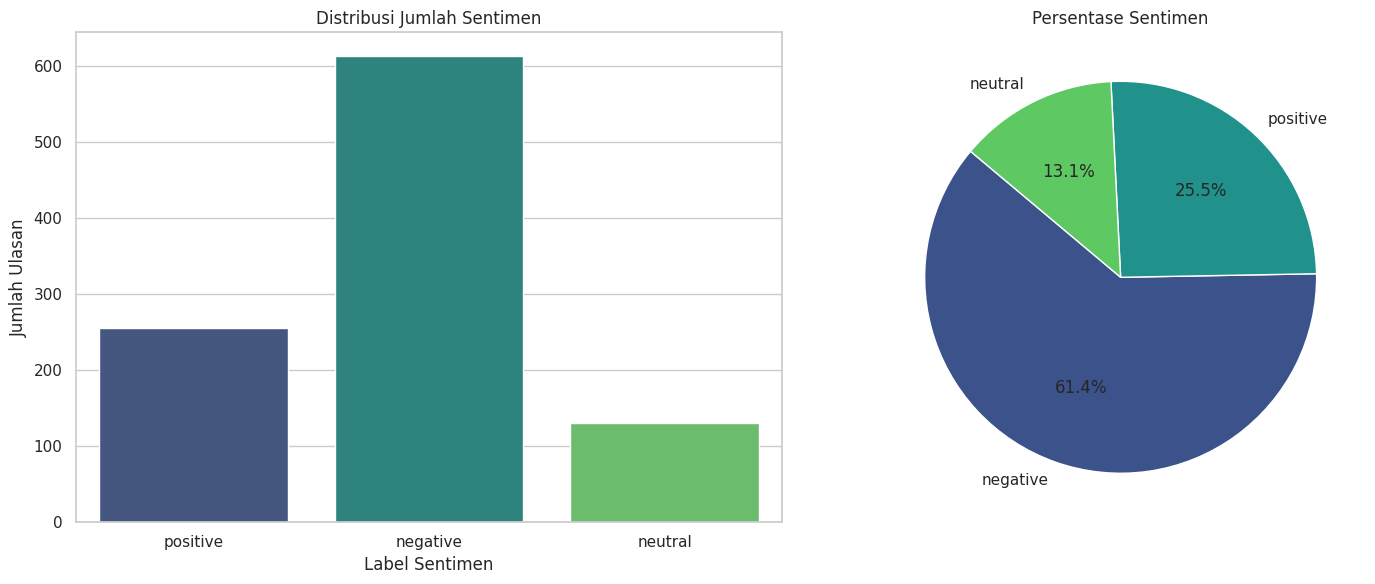

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

# Membuat figure dengan dua subplot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart: Distribusi Jumlah Sentimen
sns.countplot(x='label', data=df, hue='label', palette='viridis', ax=ax[0], legend=False)
ax[0].set_title('Distribusi Jumlah Sentimen')
ax[0].set_xlabel('Label Sentimen')
ax[0].set_ylabel('Jumlah Ulasan')

# 2. Pie Chart: Persentase Sentimen
sentiment_counts = df['label'].value_counts()
ax[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
ax[1].set_title('Persentase Sentimen')

plt.tight_layout()

# Menyimpan grafik ke dalam file
plt.savefig('visualisasi_sentimen.png', dpi=300)
print("Grafik telah disimpan sebagai 'visualisasi_sentimen.png'")

plt.show()